# The Recommendation Problem: A Matrix Full of Holes

In Course 1 we predicted the next character. Here we predict the next film a user
will want to watch.

The machinery is different but the idea is the same: find a pattern in historical
data and use it to make predictions about unseen cases. We build everything from scratch
in pure Python, plus matplotlib for visualisation.

### The task

We have 80 users and 120 items. Each user has rated a handful of items, about 7%
of the full catalogue. Everything else is unknown. The job: predict what rating any
user would give to any item they have not seen yet, and use those predictions to
recommend items they will love.

| Step | What we build | Why |
|------|--------------|-----|
| 1 | User-item matrix | Understand the structure of the problem |
| 2 | Popularity baseline | Simplest possible recommender (and its flaw) |
| 3 | Global mean baseline | Establish a numeric evaluation target |
| 4 | User and item biases | A real model: linear, but surprisingly good |
| 5 | Precision@K | The metric that actually matters |
| 6 | What's missing | The wall that motivates the rest of the course |

In [1]:
import random, math, matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
%matplotlib inline

def make_ratings(n_users=80, n_items=120, n_factors=4, density=0.07, seed=42):
    random.seed(seed)
    U = [[random.gauss(0,1) for _ in range(n_factors)] for _ in range(n_users)]
    V = [[random.gauss(0,1) for _ in range(n_factors)] for _ in range(n_items)]
    bu = [random.gauss(0, 0.3) for _ in range(n_users)]
    bv = [random.gauss(0, 0.3) for _ in range(n_items)]
    mu = 3.5
    ratings = []
    for u in range(n_users):
        for v in range(n_items):
            if random.random() < density:
                r = mu + bu[u] + bv[v] + sum(U[u][k]*V[v][k] for k in range(n_factors))
                r = max(1.0, min(5.0, r + random.gauss(0, 0.3)))
                ratings.append((u, v, round(r)))
    return ratings, n_users, n_items

def train_val_split(ratings, val_frac=0.2, seed=42):
    random.seed(seed)
    shuffled = list(ratings)
    random.shuffle(shuffled)
    split = int(len(shuffled) * (1 - val_frac))
    return shuffled[:split], shuffled[split:]

def rmse(predictions):  # [(pred, actual), ...]
    return math.sqrt(sum((p - a)**2 for p, a in predictions) / len(predictions))

ratings, N_USERS, N_ITEMS = make_ratings()
train, val = train_val_split(ratings)
print(f'{len(ratings)} ratings from {N_USERS} users on {N_ITEMS} items')
print(f'Sparsity: {1 - len(ratings)/(N_USERS*N_ITEMS):.1%} of the matrix is empty')
print(f'Train: {len(train)}, Val: {len(val)}')

645 ratings from 80 users on 120 items
Sparsity: 93.3% of the matrix is empty
Train: 516, Val: 129


## Step 1: The Structure of the Problem

Every recommendation system starts with a **user-item matrix**. Every row is a user.
Every column is an item. Every known cell holds the rating that user gave that item.

The catch: most cells are empty. A typical user rates a tiny fraction of the catalogue.
Here roughly 7% of cells are filled. That makes the matrix extremely **sparse**.

The task has a name: **matrix completion**. Given the cells we know, fill in the ones
we do not. This is fundamentally different from supervised classification, where every
training example has a label. Here, most entries have no label at all. We can only
learn from the pattern of ratings that do exist.

Below: a slice of the first 20 users and 30 items. Grey means the rating is unknown.

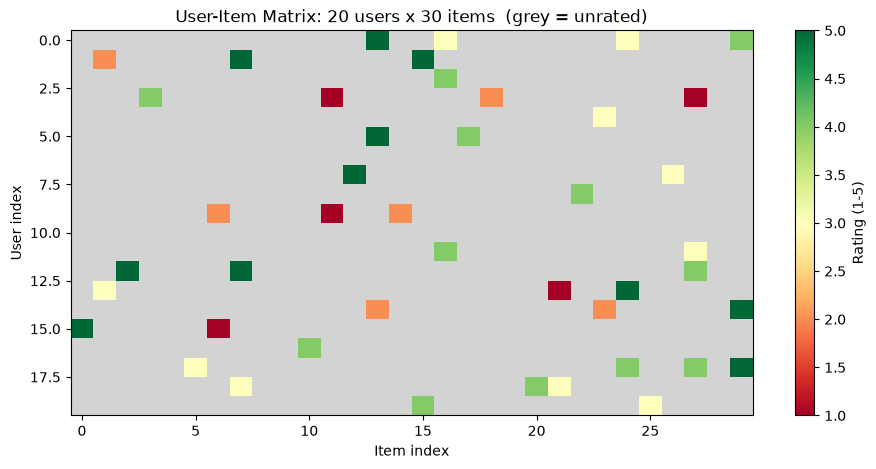

44 known ratings in this slice out of 600 cells (7.3% filled)


In [2]:
# Build the matrix (None where unrated)
matrix = [[None]*N_ITEMS for _ in range(N_USERS)]
for u, v, r in ratings:
    matrix[u][v] = r

# Extract a 20x30 slice
slice_data = np.array(
    [[matrix[u][v] if matrix[u][v] is not None else float('nan') for v in range(30)]
     for u in range(20)]
)
masked = np.ma.masked_invalid(slice_data)

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad('lightgrey')
plt.figure(figsize=(11, 5))
im = plt.imshow(masked, aspect='auto', cmap=cmap, vmin=1, vmax=5)
plt.colorbar(im, label='Rating (1-5)')
plt.xlabel('Item index')
plt.ylabel('User index')
plt.title('User-Item Matrix: 20 users x 30 items  (grey = unrated)')
plt.show()

known = int(np.sum(~np.isnan(slice_data)))
print(f'{known} known ratings in this slice out of {20*30} cells ({known/(20*30):.1%} filled)')

## Step 2: Why Popularity Isn't Enough

The simplest recommendation strategy: recommend the most popular items. Calculate each
item's average rating across all users who rated it. Sort by average. Done.

This is **Baseline 1: global popularity**. It takes a few lines to build and needs no
user-specific data to run. The flaw is visible in the output: every user gets the exact
same top-10, regardless of individual taste.

A user who rates sci-fi 5 stars and romance 1 star gets the same recommendations as a
user with the opposite preferences. Popularity is a property of items, not of the match
between a user and an item.

In [3]:
# Average rating per item, requiring at least 5 raters (fewer gives unreliable estimates)
item_rs = defaultdict(list)
for u, v, r in ratings:
    item_rs[v].append(r)

popular = sorted(
    [(v, sum(rs)/len(rs), len(rs)) for v, rs in item_rs.items() if len(rs) >= 5],
    key=lambda x: -x[1]
)

print('Top-10 most popular items (identical recommendation for every user):')
for rank, (item, avg, n) in enumerate(popular[:10], 1):
    print(f'  {rank:2d}. Item {item:3d}  avg={avg:.2f}  ({n} raters)')

Top-10 most popular items (identical recommendation for every user):
   1. Item  32  avg=4.67  (6 raters)
   2. Item  59  avg=4.60  (5 raters)
   3. Item  33  avg=4.57  (7 raters)
   4. Item  29  avg=4.56  (9 raters)
   5. Item   7  avg=4.25  (8 raters)
   6. Item  65  avg=4.20  (5 raters)
   7. Item  22  avg=4.11  (9 raters)
   8. Item   3  avg=4.00  (6 raters)
   9. Item 101  avg=4.00  (5 raters)
  10. Item 100  avg=4.00  (5 raters)


## Step 3: The Global Mean Baseline

Before building better models we need a way to measure improvement. The standard
metric for rating prediction is **RMSE** (Root Mean Squared Error):

```
RMSE = sqrt( mean( (predicted - actual)^2 ) )
```

Lower is better. RMSE of 0 means perfect predictions. RMSE of 1 means predictions
are off by about 1 star on average.

### Train/val split

We randomly hold out 20% of all ratings for evaluation. The model sees the training
ratings during fitting; we measure RMSE only on the held-out validation ratings.
This mirrors what happens in production: train on past ratings, evaluate on future ones.
(`train_val_split` was already called above; `train` and `val` are in scope.)

### The global mean predictor

Predict every unknown rating as the average training rating. It ignores everything
about the specific user and item. Its RMSE is the benchmark to beat.

In [4]:
global_mean = sum(r for u, v, r in train) / len(train)

baseline_rmse = rmse([(global_mean, r) for u, v, r in val])
print(f'Global mean: {global_mean:.3f}')
print(f'RMSE (global mean): {baseline_rmse:.4f}')

Global mean: 3.353
RMSE (global mean): 1.5351


## Step 4: Item and User Biases

The global mean ignores two obvious signals.

**User bias**: some users rate everything 4-5 stars; others rate everything 1-2. A
generous user's predicted rating should be above the global mean; a harsh user's below.

**Item bias**: some items are genuinely better than average; some are worse. A beloved
item deserves a higher prediction than a mediocre one.

The **bias model** captures both:

```
prediction(u, v) = global_mean + user_bias(u) + item_bias(v)
```

With sparse data (about 8 ratings per user), a raw average overfits: a user who
happened to rate only 5-star films looks like a universally generous rater, but may
just have rated popular films. The standard fix is **regularisation**: divide by
`count + lambda` instead of `count`. This shrinks the bias toward zero for users with
few ratings. A user with 1 rating and `lambda=10` gets a bias of just 1/(1+10) = 1/11
of their raw deviation from the global mean. As count grows, the bias converges to
the raw average.

```
user_bias(u) = sum(r - global_mean for r in user_u_train) / (count_u + lambda)
```

For users or items not seen in training the bias defaults to 0.

In [5]:
user_rs = defaultdict(list)
item_rs_train = defaultdict(list)
for u, v, r in train:
    user_rs[u].append(r)
    item_rs_train[v].append(r)

# Regularised biases: shrink toward 0 for users/items with few ratings
lam = 10
user_bias = {u: sum(r - global_mean for r in rs) / (len(rs) + lam) for u, rs in user_rs.items()}
item_bias = {v: sum(r - global_mean for r in rs) / (len(rs) + lam) for v, rs in item_rs_train.items()}

def predict_bias(u, v):
    return global_mean + user_bias.get(u, 0) + item_bias.get(v, 0)

bias_rmse = rmse([(predict_bias(u, v), r) for u, v, r in val])
print(f'RMSE (global mean):  {baseline_rmse:.4f}')
print(f'RMSE (bias model):   {bias_rmse:.4f}')
print(f'Improvement: {baseline_rmse - bias_rmse:.4f}')

RMSE (global mean):  1.5351
RMSE (bias model):   1.5127
Improvement: 0.0224


## Step 5: Rating Prediction vs Ranking

RMSE measures how accurately we predict the exact star rating. But nobody cares whether
we predict 3.8 vs 4.1. What matters: are the items we recommend the ones the user
actually likes?

This is a **ranking** problem, not a regression problem. The right metric is
**Precision@K**: of the top K items we recommend to a user, what fraction did the user
actually rate highly?

```
Precision@K = (recommended items the user liked) / K
```

We define "liked" as a rating of 4 or higher. We evaluate on the held-out validation
ratings: those are items the user actually went on to watch and rate.

Two rules: we exclude items already rated in training (no point recommending something
already seen), and we only count users who have at least one liked item in validation
(otherwise precision is undefined).

**A note on absolute values.** With 1-2 val ratings per user on average, Precision@K
values will be low in absolute terms. Even a perfect recommender can only score high
if the recommended items happen to be in the small val set. What matters is the relative
comparison: does the bias model beat the global mean baseline? A global mean recommender
has no ranking power (all items get the same score), so it picks randomly. The bias model
uses item quality to rank items, which should produce a meaningfully higher precision.

In [6]:
def precision_at_k(predict_fn, val, train, K=10, threshold=4):
    random.seed(0)  # reproducible tiebreaking when scores are equal
    user_val = defaultdict(list)
    for u, v, r in val:
        user_val[u].append((v, r))

    seen = defaultdict(set)  # items already rated in training: skip these when recommending
    for u, v, r in train:
        seen[u].add(v)

    p_list = []
    for u, items in user_val.items():
        candidates = [v for v in range(N_ITEMS) if v not in seen[u]]
        random.shuffle(candidates)  # tiebreaking: shuffle before stable sort
        top_k = set(sorted(candidates, key=lambda v: -predict_fn(u, v))[:K])
        liked = {v for v, r in items if r >= threshold}
        if liked:  # skip users with no liked items in val
            p_list.append(len(top_k & liked) / K)
    return sum(p_list) / len(p_list) if p_list else 0.0

p10_global = precision_at_k(lambda u, v: global_mean, val, train, K=10)
p10_bias   = precision_at_k(predict_bias, val, train, K=10)
print(f'Precision@10 (global mean): {p10_global:.4f}  (random ranking: no item differentiation)')
print(f'Precision@10 (bias model):  {p10_bias:.4f}')
print(f'Lift of bias over global mean: {p10_bias/p10_global:.1f}x' if p10_global > 0 else 'global mean gave 0')

Precision@10 (global mean): 0.0171  (random ranking: no item differentiation)
Precision@10 (bias model):  0.0293
Lift of bias over global mean: 1.7x


## Step 6: What's Missing

Both baselines are **linear**. The bias model decomposes a rating into three independent
terms: a global average, a user term, and an item term. These terms never interact.

This means the model cannot learn that user 5 specifically loves a cluster of items
that user 12 also loves, even if neither user has much rating overlap with others.
The model can say "user 5 is a generous rater" and "this item is well-liked," but
it cannot say "user 5 and user 12 share a particular taste, and items that appeal to
that taste should rank higher for both."

The patterns in a real rating matrix are richer than any sum of per-user and
per-item averages. Consider:

- **Genre clusters**: users who love sci-fi tend to rate the same items highly, even
  if those items have unremarkable average ratings overall.
- **Contrarian groups**: some users systematically disagree with popular opinion.
- **Niche communities**: a small group with unusual shared tastes can identify items
  that are terrible for most users but perfect for group members.

None of these patterns survive the bias model. Adding more per-user or per-item terms
will not fix this: each term still acts independently of the others.

That is the wall. The next notebook starts to break through it.

## Summary

| Model | What it predicts | Captures | Limitation |
|-------|-----------------|----------|------------|
| Global mean | Same number for everyone | Overall rating level | Ignores user and item identity |
| Bias model | global mean + user offset + item offset | User generosity, item quality | Cannot model user-item interactions |

Both models are linear. RMSE drops when we add biases, showing that user and item
identity matter. But the gap between the bias model and a perfect predictor shows
how much interaction structure remains unexplained.

The metric we will use going forward is **Precision@K**, not RMSE. RMSE minimises
prediction error. Precision@K drives us toward correctly ranking items the user
will actually want.

## Your turn

**1. Sparsity sensitivity.** Change `density=0.07` to `density=0.03` in the
`make_ratings()` call and rerun the notebook. How does each model's RMSE change?
Does the bias model gain or lose ground relative to the global mean, and why?
(Hint: think about what regularisation does when there are fewer ratings per user.)

**2. Item-only baseline.** Implement a predictor that uses
`global_mean + item_bias.get(v, 0)` with no user term. Measure its RMSE. How large
is the user bias contribution compared to the item bias contribution?

**3. Recall@K.** Precision@K answers: of the items we recommended, how many were good?
Recall@K answers the complementary question: of all the good items the user has,
how many did we recommend? Implement `recall_at_k(predict_fn, val, train, K=10,
threshold=4)`. For a user with 3 liked items in val and a top-10 list that contains
2 of them, Recall@10 = 2/3.

> Next: [Collaborative Filtering](2_collaborative_filtering.ipynb)